In [138]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

In [140]:
# load the data set

df = pd.read_csv('house_price.csv')
df.head(10)

,location,size,total_sqft,bath,price,bhk,price_per_sqft
0,Electronic City Phase II,2 BHK,1056.0,2.0,39.07,2,3699
1,Chikka Tirupathi,4 Bedroom,2600.0,5.0,120.00,4,4615
2,Uttarahalli,3 BHK,1440.0,2.0,62.00,3,4305
3,Lingadheeranahalli,3 BHK,1521.0,3.0,95.00,3,6245
4,Kothanur,2 BHK,1200.0,2.0,51.00,2,4250
5,Whitefield,2 BHK,1170.0,2.0,38.00,2,3247
6,Old Airport Road,4 BHK,2732.0,4.0,204.00,4,7467
7,Rajaji Nagar,4 BHK,3300.0,4.0,600.00,4,18181
8,Marathahalli,3 BHK,1310.0,3.0,63.25,3,4828
9,other,6 Bedroom,1020.0,6.0,370.00,6,36274


In [142]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13200 entries, 0 to 13199
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   location        13200 non-null  object 
 1   size            13200 non-null  object 
 2   total_sqft      13200 non-null  float64
 3   bath            13200 non-null  float64
 4   price           13200 non-null  float64
 5   bhk             13200 non-null  int64  
 6   price_per_sqft  13200 non-null  int64  
dtypes: float64(3), int64(2), object(2)
memory usage: 722.0+ KB


## Q1. 
Perform basic EDA (Exploratory Data Analysis)

In [145]:
print('Summary statistics:\n')
df.describe()

Summary statistics:



,total_sqft,bath,price,bhk,price_per_sqft
count,13200.000000,13200.000000,13200.000000,13200.000000,1.320000e+04
mean,1555.302783,2.691136,112.276178,2.800833,7.920337e+03
std,1237.323445,1.338915,149.175995,1.292843,1.067272e+05
min,1.000000,1.000000,8.000000,1.000000,2.670000e+02
25%,1100.000000,2.000000,50.000000,2.000000,4.267000e+03
50%,1275.000000,2.000000,71.850000,3.000000,5.438000e+03
75%,1672.000000,3.000000,120.000000,3.000000,7.317000e+03
max,52272.000000,40.000000,3600.000000,43.000000,1.200000e+07


In [147]:
print('Null values:')
df.isnull().sum()

Null values:


location          0
size              0
total_sqft        0
bath              0
price             0
bhk               0
price_per_sqft    0
dtype: int64

In [149]:
print('Distribution of price_per_sqft:')
df['price_per_sqft'].describe()

Distribution of price_per_sqft:


count    1.320000e+04
mean     7.920337e+03
std      1.067272e+05
min      2.670000e+02
25%      4.267000e+03
50%      5.438000e+03
75%      7.317000e+03
max      1.200000e+07
Name: price_per_sqft, dtype: float64

In [151]:
print('Unique locations:',df['location'].nunique())
print('Unique sizes:',df['size'].nunique())

Unique locations: 241
Unique sizes: 31


## Q2. 
Detect the outliers using following methods and remove it using methods like trimming / capping/ imputation using mean or median  
a) Mean and Standard deviation  
b) IQR(Inter quartile range method)   
c) Percentile method  
d) Z Score method

### (a): Mean and Standard Deviation

In [155]:
# Detect outliers using Mean and STD
mean_pps = df['price_per_sqft'].mean()
std_pps = df['price_per_sqft'].std()

# define outlier limits
upper_limit = mean_pps + 3 * std_pps
lower_limit = mean_pps - 3 * std_pps

# Detect the outliers
outliers_std = df[(df['price_per_sqft'] > upper_limit) | (df['price_per_sqft'] < lower_limit)]
outliers_std

,location,size,total_sqft,bath,price,bhk,price_per_sqft
345,other,3 Bedroom,11.0,3.0,74.0,3,672727
1106,other,5 Bedroom,24.0,2.0,150.0,5,625000
4044,Sarjapur Road,4 Bedroom,1.0,4.0,120.0,4,12000000
4924,other,7 BHK,5.0,7.0,115.0,7,2300000
11447,Whitefield,4 Bedroom,60.0,4.0,218.0,4,363333


In [157]:
# Remove outliers using Trimming

df_std_trimmed = df.loc[(df['price_per_sqft'] >= lower_limit) & (df['price_per_sqft'] <= upper_limit)]
print('before removing outliers:',len(df))
print('After removing outliers:',len(df_std_trimmed))
print('Outliers:',len(outliers_std))

before removing outliers: 13200
After removing outliers: 13195
Outliers: 5


In [187]:
# Removing outliers using Capping

df_std_capped = df.copy()
df_std_capped.loc[(df_std_capped['price_per_sqft']>upper_limit), 'price_per_sqft'] = upper_limit
df_std_capped.loc[(df_std_capped['price_per_sqft']<lower_limit), 'price_per_sqft'] = lower_limit

C:\Users\USER\AppData\Local\Temp\ipykernel_15940\1442183394.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '328101.8177267496' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_std_capped.loc[(df_std_capped['price_per_sqft']>upper_limit), 'price_per_sqft'] = upper_limit


### (b): IQR Method

In [162]:
# Detect outliers using IQR method

q1 = df['price_per_sqft'].quantile(0.25)
q3 = df['price_per_sqft'].quantile(0.75)
IQR = q3 - q1

lower_limit = q1 - 1.5 * IQR
upper_limit = q3 + 1.5 * IQR

# Find outliers
outliers_iqr = df.loc[(df['price_per_sqft'] < lower_limit) | (df['price_per_sqft'] > upper_limit)]
outliers_iqr

,location,size,total_sqft,bath,price,bhk,price_per_sqft
7,Rajaji Nagar,4 BHK,3300.0,4.0,600.0,4,18181
9,other,6 Bedroom,1020.0,6.0,370.0,6,36274
22,Thanisandra,4 Bedroom,2800.0,5.0,380.0,4,13571
45,HSR Layout,8 Bedroom,600.0,9.0,200.0,8,33333
48,KR Puram,2 Bedroom,800.0,1.0,130.0,2,16250
...,...,...,...,...,...,...,...
13142,other,2 BHK,1140.0,1.0,185.0,2,16228
13157,other,7 Bedroom,1400.0,7.0,218.0,7,15571
13185,Hulimavu,1 BHK,500.0,1.0,220.0,1,44000
13186,other,4 Bedroom,1200.0,5.0,325.0,4,27083


In [164]:
# Remove outliers using Trimming

df_iqr_trimmed = df.loc[(df['price_per_sqft'] >= lower_limit) & (df['price_per_sqft'] <= upper_limit)]
print('before removing outliers:',len(df))
print('After removing outliers:',len(df_iqr_trimmed))
print('Outliers:',len(outliers_iqr))

before removing outliers: 13200
After removing outliers: 11935
Outliers: 1265


In [166]:
# Removing outliers using Imputation(Median)

median_pps = df['price_per_sqft'].median()
df_imputed_iqr = df.copy()
df_imputed_iqr.loc[(df_imputed_iqr['price_per_sqft'] < lower_limit) | (df_imputed_iqr['price_per_sqft'] > upper_limit), 'price_per_sqft'] = median_pps

### (c): Percentile Method

In [169]:
# Detect outliers using Percentile method(less than 5% and greater than 95% )

upper_limit = df['price_per_sqft'].quantile(0.95)
lower_limit = df['price_per_sqft'].quantile(0.05)

# Find outliers
outliers_percentile = df.loc[(df['price_per_sqft'] < lower_limit) | (df['price_per_sqft'] > upper_limit)]
outliers_percentile

,location,size,total_sqft,bath,price,bhk,price_per_sqft
7,Rajaji Nagar,4 BHK,3300.0,4.0,600.0,4,18181
9,other,6 Bedroom,1020.0,6.0,370.0,6,36274
20,Kengeri,1 BHK,600.0,1.0,15.0,1,2500
41,Sarjapur Road,3 BHK,1254.0,3.0,38.0,3,3030
45,HSR Layout,8 Bedroom,600.0,9.0,200.0,8,33333
...,...,...,...,...,...,...,...
13157,other,7 Bedroom,1400.0,7.0,218.0,7,15571
13185,Hulimavu,1 BHK,500.0,1.0,220.0,1,44000
13186,other,4 Bedroom,1200.0,5.0,325.0,4,27083
13191,Ramamurthy Nagar,7 Bedroom,1500.0,9.0,250.0,7,16666


In [171]:
# Remove outliers using Trimming

df_percentile_trimmed = df.loc[(df['price_per_sqft'] >= lower_limit) & (df['price_per_sqft'] <= upper_limit)]
print('before removing outliers:',len(df))
print('After removing outliers:',len(df_percentile_trimmed))
print('Outliers:',len(outliers_percentile))

before removing outliers: 13200
After removing outliers: 11880
Outliers: 1320


In [173]:
# Removing outliers using Capping

df_percentile_capped = df.copy()
df_percentile_capped.loc[(df_percentile_capped['price_per_sqft']>upper_limit), 'price_per_sqft'] = upper_limit
df_percentile_capped.loc[(df_percentile_capped['price_per_sqft']<lower_limit), 'price_per_sqft'] = lower_limit

C:\Users\USER\AppData\Local\Temp\ipykernel_15940\3510617931.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '15312.099999999984' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_percentile_capped.loc[(df_percentile_capped['price_per_sqft']>upper_limit), 'price_per_sqft'] = upper_limit


### (c): Z Score Method

In [176]:
# Calculate Z-scores
z_scores = np.abs(stats.zscore(df['price_per_sqft']))
threshold = 3

# Find outliers
outliers_z = df[z_scores > threshold]
outliers_z

,location,size,total_sqft,bath,price,bhk,price_per_sqft
345,other,3 Bedroom,11.0,3.0,74.0,3,672727
1106,other,5 Bedroom,24.0,2.0,150.0,5,625000
4044,Sarjapur Road,4 Bedroom,1.0,4.0,120.0,4,12000000
4924,other,7 BHK,5.0,7.0,115.0,7,2300000
11447,Whitefield,4 Bedroom,60.0,4.0,218.0,4,363333


In [178]:
# Remove outliers using Trimming

df_z_trimmed = df[z_scores <= threshold]
print('before removing outliers:',len(df))
print('After removing outliers:',len(df_z_trimmed))
print('Outliers:',len(outliers_z))

before removing outliers: 13200
After removing outliers: 13195
Outliers: 5


In [180]:
# Removing outliers using Capping
upper_limit = mean_pps + 3 * std_pps
lower_limit = mean_pps - 3 * std_pps

df_capped_z = df.copy()
df_capped_z.loc[(df_capped_z['price_per_sqft']>upper_limit), 'price_per_sqft'] = upper_limit
df_capped_z.loc[(df_capped_z['price_per_sqft']<lower_limit), 'price_per_sqft'] = lower_limit

C:\Users\USER\AppData\Local\Temp\ipykernel_15940\2537524266.py:6: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '328101.8177267496' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_capped_z.loc[(df_capped_z['price_per_sqft']>upper_limit), 'price_per_sqft'] = upper_limit


## Q3.

##### Create a box plot and use this to determine which method seems to work best to remove outliers for this data? 

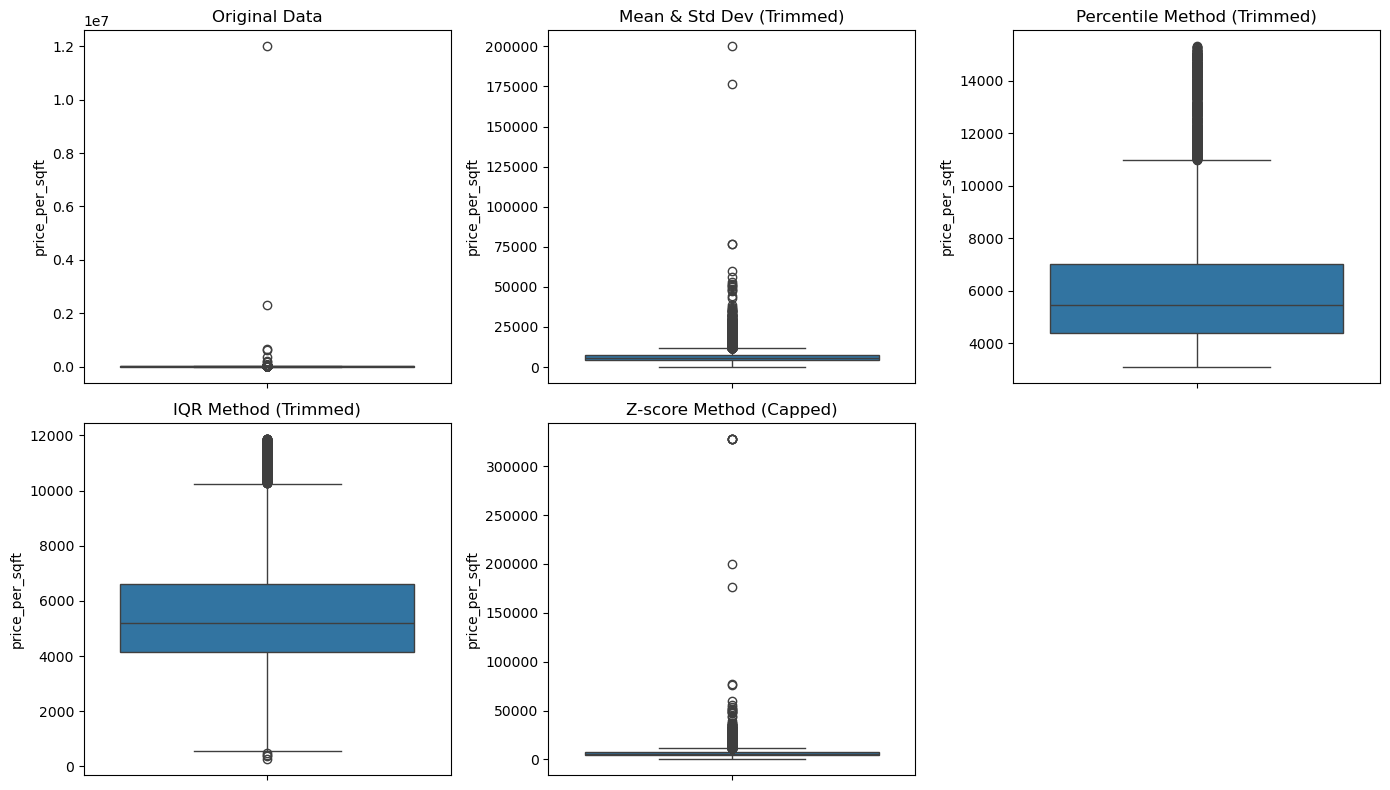

In [197]:
plt.figure(figsize=(14, 8))

# 1. Original Data
plt.subplot(2, 3, 1)
sns.boxplot(y=df['price_per_sqft'])
plt.title("Original Data")

# 2. Mean & Std Dev (Trimmed)
plt.subplot(2, 3, 2)
sns.boxplot(y=df_std_trimmed['price_per_sqft'])
plt.title("Mean & Std Dev (Trimmed)")

# 3. Percentile Method (Trimmed)
plt.subplot(2, 3, 3)
sns.boxplot(y=df_percentile_trimmed['price_per_sqft'])
plt.title("Percentile Method (Trimmed)")

# 4. IQR (Trimmed)
plt.subplot(2, 3, 4)
sns.boxplot(y=df_iqr_trimmed['price_per_sqft'])
plt.title("IQR Method (Trimmed)")

# 5. Z-Score Method (Capped)
plt.subplot(2, 3, 5)
sns.boxplot(y=df_capped_z['price_per_sqft'])
plt.title("Z-score Method (Capped)")

plt.tight_layout()
plt.show()

##### IQR Method and Percentile Method usually perform well.

## Q4.
Draw histplot to check the normality of the column(price per sqft column) and perform transformations if needed.  
Check the skewness and kurtosis before and after the transformation.

In [35]:
from scipy.stats import skew, kurtosis

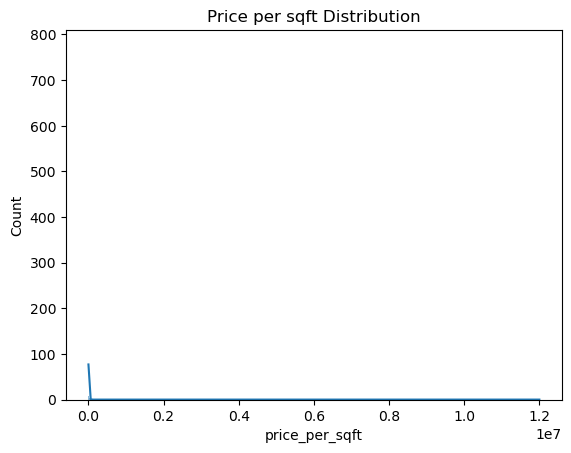

In [99]:
# Price per square feet distribution
sns.histplot(df['price_per_sqft'], kde=True)
plt.title('Price per sqft Distribution')
plt.show()

In [37]:
# Skewness & Kurtosis
orig_skew = skew(df['price_per_sqft'])
orig_kurt = kurtosis(df['price_per_sqft'])

print(f"Skewness before transformation: {orig_skew:.2f}")
print(f"Kurtosis before transformation: {orig_kurt:.2f}")

Skewness before transformation: 108.27
Kurtosis before transformation: 12090.63


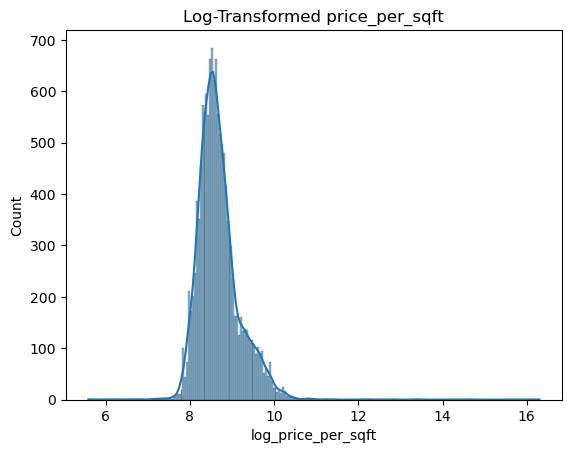

In [93]:
# Apply Log Transformation
df['log_price_per_sqft'] = np.log1p(df['price_per_sqft'])

# Plot histogram after transformation
sns.histplot(df['log_price_per_sqft'], kde=True)
plt.title('Log-Transformed price_per_sqft')
plt.show()


In [103]:
# Skewness & Kurtosis after log transformation
log_skew = skew(df['log_price_per_sqft'])
log_kurt = kurtosis(df['log_price_per_sqft'])

print(f"Skewness after transformation: {log_skew:.2f}")
print(f"Kurtosis after transformation: {log_kurt:.2f}")


Skewness after transformation: 1.40
Kurtosis after transformation: 9.20


## Q5.
Check the correlation between all the numerical columns and plot heatmap

In [113]:
# Select only numeric columns
numeric_df = df.select_dtypes(include=['number'])
numeric_df

,total_sqft,bath,price,bhk,price_per_sqft,log_price_per_sqft
0,1056.0,2.0,39.07,2,3699,8.216088
1,2600.0,5.0,120.00,4,4615,8.437284
2,1440.0,2.0,62.00,3,4305,8.367765
3,1521.0,3.0,95.00,3,6245,8.739697
4,1200.0,2.0,51.00,2,4250,8.354910
...,...,...,...,...,...,...
13195,3453.0,4.0,231.00,5,6689,8.808369
13196,3600.0,5.0,400.00,4,11111,9.315781
13197,1141.0,2.0,60.00,2,5258,8.567696
13198,4689.0,4.0,488.00,4,10407,9.250330


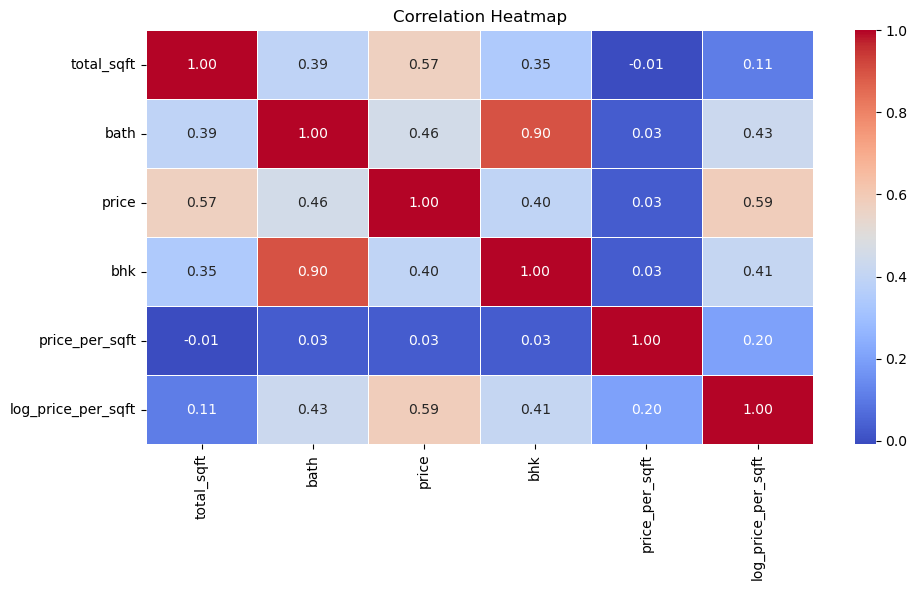

In [205]:
# Compute correlation matrix
correlation_matrix = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

## Q6.  
Draw Scatter plot between the variables to check the correlation between them.

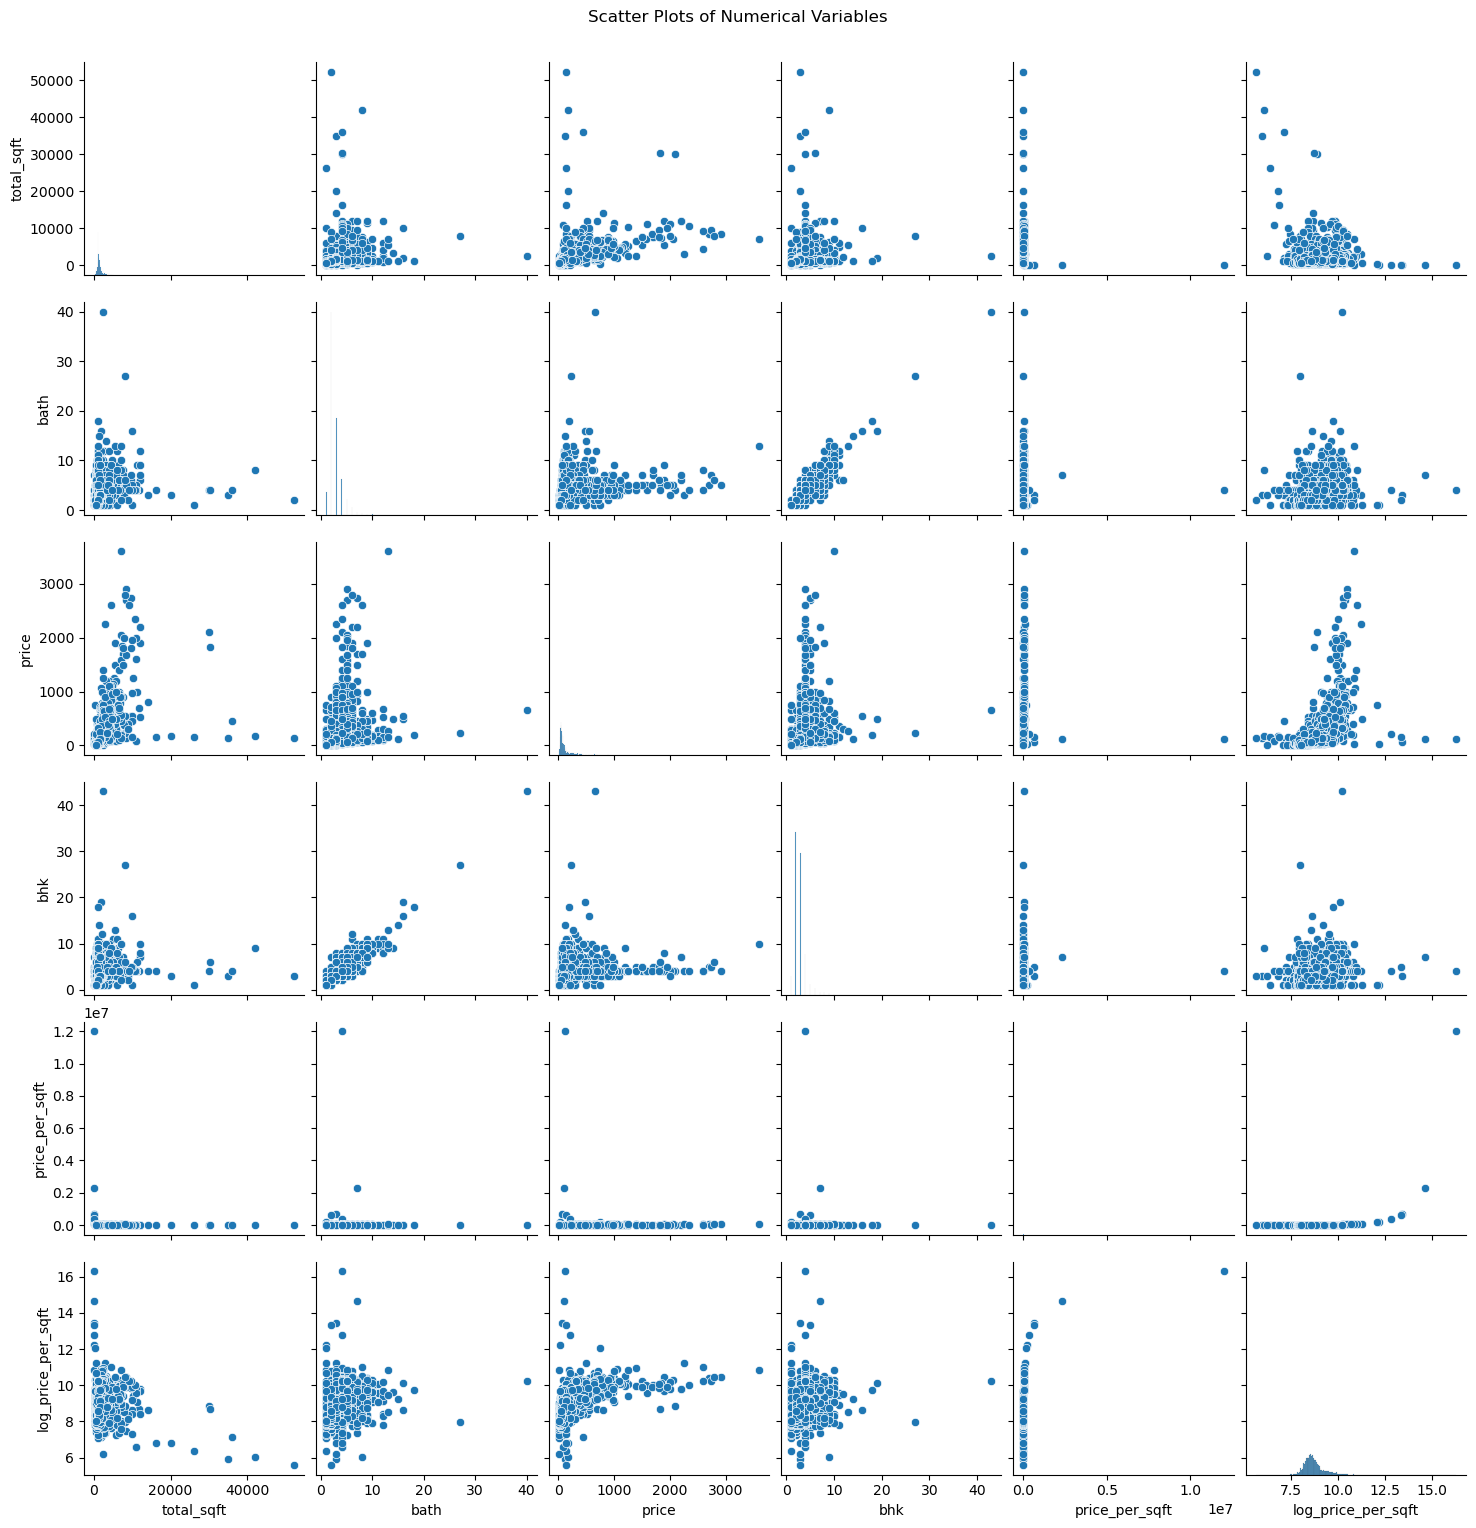

In [134]:
# Plot scatter plots between all numerical columns
sns.pairplot(df.select_dtypes(include='number'))
plt.suptitle("Scatter Plots of Numerical Variables", y=1.02)
plt.show()

#### Observations:

price vs total_sqft shows a clear positive correlation – as size increases, price increases.

bhk and bath are also positively related to price.

price_per_sqft has a lot of outliers, especially in its relationship with other variables.

The transformation log_price_per_sqft looks more normally distributed than price_per_sqft, which helps for statistical modeling.
